# Common stuff
### based on QCD on the Lattice Ch. 3.3

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
#import tools
from scipy.optimize import curve_fit


# Wilson Loop
### based on ch. 3.4 and 3.5

In [196]:
with h5py.File("../../h5/HotMultiPlaq.h5", "r") as f:
    f.visit(print)

Configuration
Configuration/0
Configuration/0/T0
Configuration/0/T0/loops
Configuration/0/T0/r
Configuration/0/T1
Configuration/0/T1/loops
Configuration/0/T1/r
Configuration/0/T2
Configuration/0/T2/loops
Configuration/0/T2/r
Configuration/0/T3
Configuration/0/T3/loops
Configuration/0/T3/r
Configuration/0/T4
Configuration/0/T4/loops
Configuration/0/T4/r
Configuration/1
Configuration/1/T0
Configuration/1/T0/loops
Configuration/1/T0/r
Configuration/1/T1
Configuration/1/T1/loops
Configuration/1/T1/r
Configuration/1/T2
Configuration/1/T2/loops
Configuration/1/T2/r
Configuration/1/T3
Configuration/1/T3/loops
Configuration/1/T3/r
Configuration/1/T4
Configuration/1/T4/loops
Configuration/1/T4/r
Configuration/10
Configuration/10/T0
Configuration/10/T0/loops
Configuration/10/T0/r
Configuration/10/T1
Configuration/10/T1/loops
Configuration/10/T1/r
Configuration/10/T2
Configuration/10/T2/loops
Configuration/10/T2/r
Configuration/10/T3
Configuration/10/T3/loops
Configuration/10/T3/r
Configuration/1

In [197]:
# dimensionen machen murks..
def bootstrap(iterations, data):

    n = data.shape[0]

    indices = np.random.randint(0, n, size=(iterations, n))
    boot_samples = data[indices]       

    boot_means = np.mean(boot_samples, axis=1) 

    mean = np.mean(boot_means, axis=0)
    std  = np.std(boot_means, axis=0)

    return mean, std

In [198]:
def read_wilson_loops(filename, B, path = "Configuration", data_name = "loops"):

    all_data = []

    with h5py.File(filename, "r") as f:

        config_keys = list(f[path].keys())

        for cfg in config_keys: 

            T_keys = list(f[f"{path}/{cfg}"].keys())
            cfg_data = []

            for T in T_keys:

                data = f[f"{path}/{cfg}/{T}/{data_name}"][:]
                cfg_data.append(data)

            all_data.append(cfg_data)

    all_data = np.array(all_data)
    means = []
    stds = []

    for r in range(all_data.shape[2]):

        means_r = []
        stds_r = []

        for nt in range(all_data.shape[1]):

            data = all_data[:, nt, r]
            #print("Shape of data:", data.shape)
            #print(all_data.shape)
            #print(all_data[0][0].shape)
            mean, std = bootstrap(B, data)

            means_r.append(mean)
            stds_r.append(std)
        
        means.append(means_r)
        stds.append(stds_r)
    return np.array(means), np.array(stds)
    

In [199]:
means, stds = read_wilson_loops(
    filename="../../h5/HotMultiPlaq.h5",
    B=200
)

In [356]:
print(means[2,:])

[[-0.03918199 -0.03185129]
 [-0.01306014  0.02115331]
 [-0.01140496 -0.01885094]
 [ 0.01309929  0.00074636]
 [ 0.05774063 -0.03574099]]


### Fit for $a V(an)$ and $C$, with $aV(an)=A+\frac{B}{n} + \sigma n$

#### try to make it better

In [316]:
W_data = means[:, :, 0]
W_err = stds[:, :, 0]

N_r, N_t = W_data.shape

n_values = np.arange(1, N_r + 1)
t_values = np.arange(1, N_t+1)

#-----------------------------------------------------

def wilson_loop_exp(t, C, aV):

    return C * np.exp(-t * aV)


def wilson_extract_V(n, Aa, B, sigmaa2):

    return Aa + B / n + sigmaa2 * n

#----------------------------------------------------


def fit_potential_from_W(W_data, W_err, t_values):

    N_r, N_t = W_data.shape

    aV_values = []
    aV_errors = []
    C_values = []
    C_errors = []

    for i in range(N_r):

            W = W_data[i, :]
            err = W_err[i, :]
            p0 = [W[0], 0.5]

            popt, pcov = curve_fit(
                wilson_loop_exp,
                t_values,
                W,
                sigma=err,
                absolute_sigma=True,
                p0=p0,
                maxfev=10000
            )

            C, aV = popt
            C_err, aV_err = np.sqrt(np.diag(pcov))

            C_values.append(C)
            C_errors.append(C_err)
            aV_values.append(aV)
            aV_errors.append(aV_err)

    return (np.array(aV_values),
                np.array(aV_errors),
                np.array(C_values),
                np.array(C_errors))


#-------------------------------------------------------

aV, aV_err, C, C_err = fit_potential_from_W( W_data, W_err, t_values)

In [352]:
def fit_static_potential(n_values, aV, aV_err):

    p0 = [0.5, 0.5, 0.5]

    popt, pcov = curve_fit(
        wilson_extract_V,
        n_values,
        aV,
        sigma= aV_err,
        absolute_sigma=True,
        p0=p0,
        maxfev=10000
    )

    Aa, B, sigmaa2 = popt
    Aa_err, B_err, sigmaa2_err = np.sqrt(np.diag(pcov))


    return Aa, B, sigmaa2, Aa_err, B_err, sigmaa2_err 

In [366]:
Aa, B, sigmaa2, Aa_err, B_err, sigmaa2_err  = fit_static_potential(  n_values, aV, aV_err)

print(B)

33.51306698874306


#### Sanity check

In [341]:
def plot_wilson_vs_t(n_index, W_data, W_err, t_values):

    plt.errorbar(t_values, W_data[n_index, :], yerr=W_err[n_index, :],fmt='.')

    plt.xlabel(r"$t$")
    plt.ylabel(r"$\langle W(n,t) \rangle$")
    plt.show()

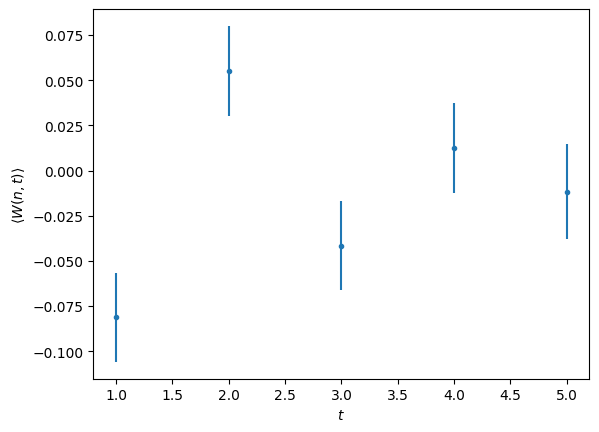

In [349]:
plot_wilson_vs_t(4, W_data, W_err, t_values)

In [343]:
def plot_wilson_vs_n(t_index, W_data, W_err, n_values):

    plt.errorbar(n_values, W_data[:, t_index], yerr=W_err[:, t_index],fmt='.')

    plt.xlabel(r"$n$")
    plt.ylabel(r"$\langle W(n,t) \rangle$")
    plt.show()

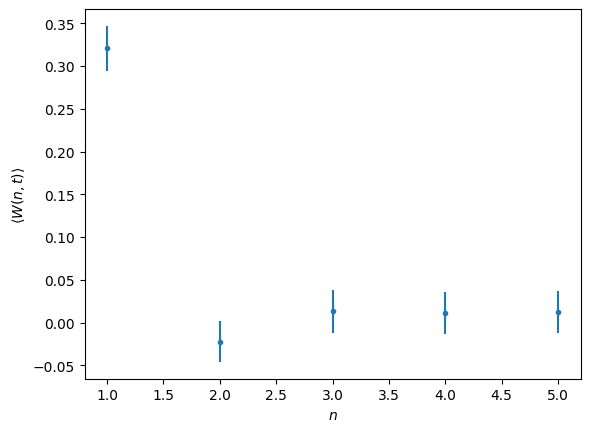

In [344]:
plot_wilson_vs_n(t_index=3, W_data=W_data, W_err=W_err, n_values=n_values)

### Get Sommer parameter and lattice spacing

In [322]:
r0_a = np.sqrt((1.65 + B) / (sigmaa2))
print(r0_a)

1.726134930473164


In [323]:
r0_phys = 0.5 #fm
a = r0_phys / r0_a
print(a)

0.2896644932982969


In [324]:
# something is very wrong...

### Get the potential $V(r)$

In [367]:
sigma = sigmaa2 / a**2
A = Aa / a
print(A)

def V_phys(r):

    return A + B / r + sigma*r

-156.28485508429196


In [359]:
r_val = a * n_values
V_val = V_phys(r_val)

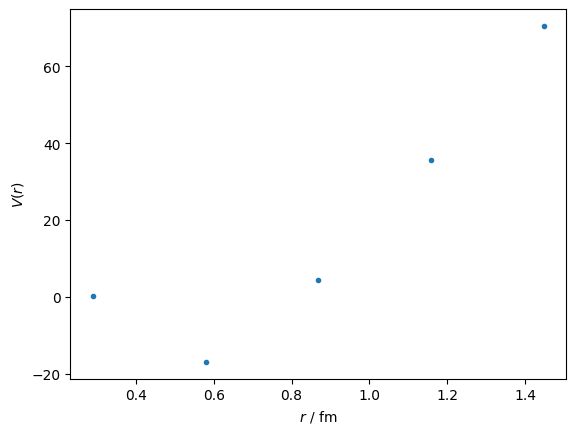

In [363]:
plt.plot(r_val, V_val, '.')
plt.xlabel(r"$r$ / fm")
plt.ylabel(r"$V(r)$")
plt.show()

# Polyakov Loop
### based on ch. 4.5.4